## **AIVLE School 미니프로젝트 8기 AI트랙 1차** ##
## **공공데이터를 활용한 <span style="color:skyblue">미세먼지 농도</span> 예측**
---
## [step 1,2] 데이터 분석 및 전처리

## **0.프로젝트 소개**

### (1) 수행 목표
- 미세먼지 농도를 예측하는 머신러닝 모델을 만드세요.

#### 우리가 풀어야 하는 문제는 무엇인가요?
* 서울 지역의 미세먼지 데이터와 날씨 데이터를 활용하여, 미세먼지 예측에 관련 있는 데이터 항목으로 데이터를 구성, 전처리 하여 미세먼지 농도를 예측하는 머신러닝 모델 구현

### (2) 데이터 소개

#### 1) 기본 데이터

* 학습 데이터
    * air_2024.csv : 2024년 미세먼지 데이터
    * weather_2024.csv : 2024년 날씨 데이터
* 테스트 데이터
    * air_2025.csv : 2025년 미세먼지 데이터
    * weather_2025.csv : 2025년 날씨 데이터

#### 2) 데이터셋의 변수 소개(weather_202x)

* 증기압: 증기가 고체 또는 액체와 동적 평형 상태에 있을 때 증기의 압력 (증기가 되려는 힘)
* 이슬점 온도: 불포화 상태의 공기가 냉각될 때, 포화 상태에 도달하여 수증기의 응결이 시작되는 온도
* 일조: 일정한 물체나 땅의 겉면에 태양 광선이 비치는 시간 (1시간 중 비율)
* 일사(량): 태양으로부터 오는 태양 복사 에너지가 지표에 닿는 양 (면적당 에너지 량)
* 전운량: 하늘을 육안으로 관측하여 전부 구름일 때 10, 구름이 덮고 있는 하늘의 비율에 따라 0~10
* 중하층운량: 중층과 하층에 있는 구름의 분포량(중하층 구름이 날씨에 영향 주므로 따로 표기)
* 운형(운형약어): 구름의 종류. 약어 코드로 기재됨
* 최저운고: 가장 낮은 구름의 높이
* 현상번호(국내식): 비, 소낙비, 싸락눈, 눈보라 등의 기상현상을 나타낸 코드번호
* 지면온도: 지면 0cm 온도
* 지중온도: 땅 속 온도변수1

## **1.환경설정**

* 세부 요구사항
    - 경로 설정 : 프로젝트 폴더를 준비하고 데이터를 로딩하시오.
        * 구글코랩
            * 구글 드라이브에 project 폴더를 만들고,
            * 데이터 파일을 복사해 넣습니다.
        * (필요시) 로컬 수행(Ananconda)
            * 제공된 압축파일을 다운받아 압축을 풀고
            * anaconda의 root directory(보통 C:/Users/< ID > 에 project 폴더를 만들고, 복사해 넣습니다.
            
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.

### (1) 경로 설정
* 구글 코랩 (또는 필요시 로컬)를 사용하시면 됩니다.

#### 1) 구글 코랩 수행

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/Aivle/미니프로젝트/1차_미세먼지/'

#### 2) (희망시) 로컬 수행(Anaconda)
* project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [ ]:
# path = 'C:/Users/User/project/'

### (2) 라이브러리 설치 및 불러오기

#### 1) 라이브러리 설치 및 로딩

In [ ]:
# 필요한 라이브러리 설치 및 불러오기

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from statsmodels.graphics.mosaicplot import mosaic
from scipy import stats as spst
import statsmodels.api as sm
import joblib

# 더 필요한 라이브러리를 아래에 추가합니다.




> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
<small>(해결되지 않는다면 아래 Colab 한글 깨짐 현상 해결법 참고)<br>https://developnote.tistory.com/165#google_vignette </small>

In [ ]:
# (Jupyter) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
plt.rc('font', family='Malgun Gothic')
sns.set(font="Malgun Gothic",#"NanumGothicCoding",
        rc={"axes.unicode_minus":False}, # 마이너스 부호 깨짐 현상 해결
        style='darkgrid')

In [ ]:
# (Colab) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
!apt -qq -y install fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

import matplotlib as mpl
import matplotlib.font_manager as fm
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

### (3) 데이터 불러오기
* Pandas 라이브러리를 활용해서 'air_2024.csv'파일을 'air_24' 변수에,'air_2025.csv'파일을 'air_25' 변수에 저장하고 그 데이터를 확인하세요.
 ( 구분자/인코딩 sep = ',',encoder = 'cp949')

* Pandas 라이브러리를 활용해서 'weather_2024.csv'파일을 'weather_24' 변수에,'weather_2025.csv'파일을 'weather_25' 변수에 저장하고 그 데이터를 확인하세요.
 ( 구분자/인코딩 sep = ',',encoder = 'cp949')

#### 1) 데이터로딩

In [ ]:
%cd '{path}'

/content/drive/MyDrive/Aivle/미니프로젝트/1차_미세먼지


In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 데이터 로딩
air_24 = pd.read_csv('air_2024.csv', encoding='cp949')
air_25 = pd.read_csv('air_2025.csv', encoding='cp949')
weather_24 = pd.read_csv('weather_2024.csv', encoding='cp949')
weather_25 = pd.read_csv('weather_2025.csv', encoding='cp949')

#### 2) 기본 정보 조회
- 데이터를 head, tail. describe, info 등을 활용하여 확인하세요.

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
print(air_24.head())
print('-'*100)
print(air_24.tail())
print('-'*100)
print(air_24.describe())
print('-'*100)
print(air_24.info())

       지역     망   측정소코드 측정소명        측정일시     SO2    CO      O3     NO2  PM10  \
0  서울 종로구  도시대기  111123  종로구  2024010101  0.0031  1.21  0.0022  0.0425  29.0   
1  서울 종로구  도시대기  111123  종로구  2024010102  0.0032  1.16  0.0020  0.0393  24.0   
2  서울 종로구  도시대기  111123  종로구  2024010103  0.0030  1.00  0.0022  0.0359  23.0   
3  서울 종로구  도시대기  111123  종로구  2024010104  0.0029  0.98  0.0021  0.0355  23.0   
4  서울 종로구  도시대기  111123  종로구  2024010105  0.0031  1.02  0.0020  0.0371  25.0   

   PM25                주소  
0  23.0  서울 종로구 종로35가길 19  
1  21.0  서울 종로구 종로35가길 19  
2  19.0  서울 종로구 종로35가길 19  
3  18.0  서울 종로구 종로35가길 19  
4  21.0  서울 종로구 종로35가길 19  
----------------------------------------------------------------------------------------------------
          지역     망   측정소코드 측정소명        측정일시     SO2    CO      O3     NO2  \
8779  서울 종로구  도시대기  111123  종로구  2024123120  0.0027  0.36  0.0284  0.0166   
8780  서울 종로구  도시대기  111123  종로구  2024123121  0.0026  0.36  0.0257  0.0187   
8781  서울 종로구  도시대기 

In [ ]:
print(air_25.head())
print('-'*100)
print(air_25.tail())
print('-'*100)
print(air_25.describe())
print('-'*100)
print(air_25.info())

       지역     망   측정소코드 측정소명        측정일시     SO2    CO      O3     NO2  PM10  \
0  서울 종로구  도시대기  111123  종로구  2025010101  0.0026  0.68  0.0045  0.0425  23.0   
1  서울 종로구  도시대기  111123  종로구  2025010102  0.0023  0.73  0.0034  0.0457  24.0   
2  서울 종로구  도시대기  111123  종로구  2025010103  0.0025  0.77  0.0032  0.0478  23.0   
3  서울 종로구  도시대기  111123  종로구  2025010104  0.0028  0.76  0.0036  0.0458  31.0   
4  서울 종로구  도시대기  111123  종로구  2025010105  0.0029  0.72  0.0035  0.0460  31.0   

   PM25                주소  
0  12.0  서울 종로구 종로35가길 19  
1  11.0  서울 종로구 종로35가길 19  
2  13.0  서울 종로구 종로35가길 19  
3  17.0  서울 종로구 종로35가길 19  
4  16.0  서울 종로구 종로35가길 19  
----------------------------------------------------------------------------------------------------
          지역     망   측정소코드 측정소명        측정일시     SO2    CO      O3     NO2  \
2875  서울 종로구  도시대기  111123  종로구  2025043020  0.0031  0.39  0.0591  0.0225   
2876  서울 종로구  도시대기  111123  종로구  2025043021  0.0030  0.50  0.0553  0.0273   
2877  서울 종로구  도시대기 

In [ ]:
print(weather_24.head())
print('-'*100)
print(weather_24.tail())
print('-'*100)
print(weather_24.describe())
print('-'*100)
print(weather_24.info())

    지점 지점명               일시  기온(°C)  기온 QC플래그  강수량(mm)  강수량 QC플래그  풍속(m/s)  \
0  108  서울  2024-01-01 0:00     0.6       NaN      NaN        9.0      1.9   
1  108  서울  2024-01-01 1:00     0.5       NaN      NaN        NaN      2.2   
2  108  서울  2024-01-01 2:00     0.4       NaN      NaN        NaN      0.4   
3  108  서울  2024-01-01 3:00    -0.1       NaN      NaN        NaN      1.7   
4  108  서울  2024-01-01 4:00    -0.2       NaN      NaN        NaN      2.2   

   풍속 QC플래그  풍향(16방위)  ...  최저운고(100m )  시정(10m)  지면상태(지면상태코드)  현상번호(국내식)  \
0       NaN      20.0  ...          NaN      394           NaN       19.0   
1       NaN      50.0  ...          NaN      402           NaN       19.0   
2       NaN       0.0  ...         13.0      616           NaN       19.0   
3       NaN      20.0  ...         13.0      265           NaN       19.0   
4       NaN      20.0  ...         14.0      203           NaN       19.0   

   지면온도(°C)  지면온도 QC플래그  5cm 지중온도(°C)  10cm 지중온도(°C)  20cm 지중온도(°C) 

In [ ]:
print(weather_25.head())
print('-'*100)
print(weather_25.tail())
print('-'*100)
print(weather_25.describe())
print('-'*100)
print(weather_25.info())

    지점 지점명               일시  기온(°C)  기온 QC플래그  강수량(mm)  강수량 QC플래그  풍속(m/s)  \
0  108  서울  2025-01-01 0:00    -1.2       NaN      NaN        9.0      0.7   
1  108  서울  2025-01-01 1:00    -1.7       NaN      NaN        NaN      1.1   
2  108  서울  2025-01-01 2:00    -1.8       NaN      NaN        NaN      0.5   
3  108  서울  2025-01-01 3:00    -2.0       NaN      NaN        NaN      1.9   
4  108  서울  2025-01-01 4:00    -2.3       NaN      NaN        NaN      2.2   

   풍속 QC플래그  풍향(16방위)  ...  최저운고(100m )  시정(10m)  지면상태(지면상태코드)  현상번호(국내식)  \
0       NaN       290  ...          NaN     3546           NaN        NaN   
1       NaN       250  ...          NaN     3274           NaN        NaN   
2       NaN       340  ...          NaN     3460           NaN        NaN   
3       NaN        20  ...          NaN     3256           NaN        NaN   
4       NaN        20  ...          NaN     3111           NaN        NaN   

   지면온도(°C)  지면온도 QC플래그  5cm 지중온도(°C)  10cm 지중온도(°C)  20cm 지중온도(°C) 

## **2.EDA 1단계 - 데이터 기본 탐색 및 분석**

* 단변량 분석은 데이터분석의 매우 기초적인 분석기법으로, 독립적인 개별 변수가 가지고있는 특성들을 이해하는 과정입니다.

    * <span style="color: green"> 4 ~ 5개 변수를 뽑아 확인해보세요 </span>
    * <span style="color: green"> 개별 변수에 대해 아래 사항들을 분석해보세요. </span>

        - 변수가 수치형인지, 범주형인지
        - 결측치 존재 여부 및 조치 방안
        - 기초 통계량 확인
        - 데이터 분포 확인
        - 변수가 내포하고 있는 의미 파악을 위한 추가 분석
        - 위 정보로부터 파악한 내용 정리


### (1) 변수1 : 측정일시

In [ ]:
# 변수가 수치형인지, 범주형인지 확인해 보세요
temp = air_24['측정일시']
temp.dtype

dtype('int64')

In [ ]:
air_24['측정일시']

,측정일시
0,2024010101
1,2024010102
2,2024010103
3,2024010104
4,2024010105
...,...
8779,2024123120
8780,2024123121
8781,2024123122
8782,2024123123


In [ ]:
# 결측치 존재 여부를 확인하고 조치 방안을 검토해 보세요
temp.isnull().sum()

np.int64(0)

In [ ]:
# 기초 통계량을 확인해 보세요
temp.describe()

,측정일시
count,8.784000e+03
mean,2.024067e+09
std,3.453123e+04
min,2.024010e+09
25%,2.024040e+09
50%,2.024070e+09
75%,2.024100e+09
max,2.024123e+09


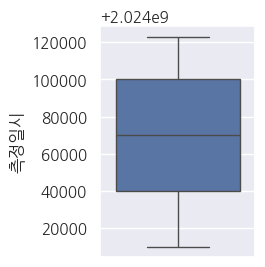

In [ ]:
# 데이터 분포를 시각해 보세요
plt.figure(figsize=(2, 3))
sns.boxplot(temp)
plt.show()

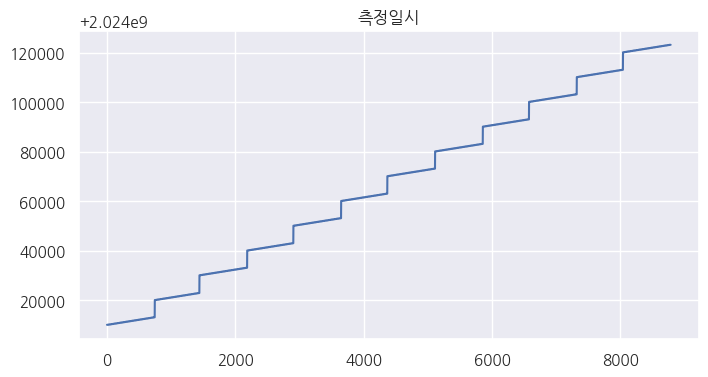

In [ ]:
# 변수가 내포하고 있는 의미 파악을 위한 추가 분석
plt.figure(figsize=(8, 4))
plt.plot(temp)
plt.title('측정일시')
plt.show()

In [ ]:
# 위 정보로부터 파악한 내용을 서술해 보세요


In [ ]:
# air 는 0101 1시부터 weather 은 0101 00부터

### (2) 변수2

In [ ]:
# 변수가 수치형인지, 범주형인지 확인해 보세요
temp = weather_24['강수량(mm)']
temp.dtype

dtype('float64')

In [ ]:
# 결측치 존재 여부를 확인하고 조치 방안을 검토해 보세요
temp.isnull().sum()

np.int64(7828)

In [ ]:
# 기초 통계량을 확인해 보세요
temp.describe()

,강수량(mm)
count,956.000000
mean,1.371757
std,3.330638
min,0.000000
25%,0.000000
50%,0.100000
75%,1.100000
max,39.000000


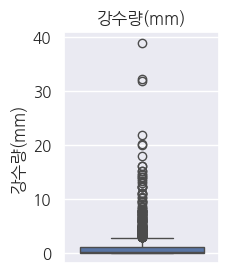

In [ ]:
# 데이터 분포를 시각해 보세요
plt.figure(figsize=(2, 3))
sns.boxplot(temp)
plt.title('강수량(mm)')
plt.show()

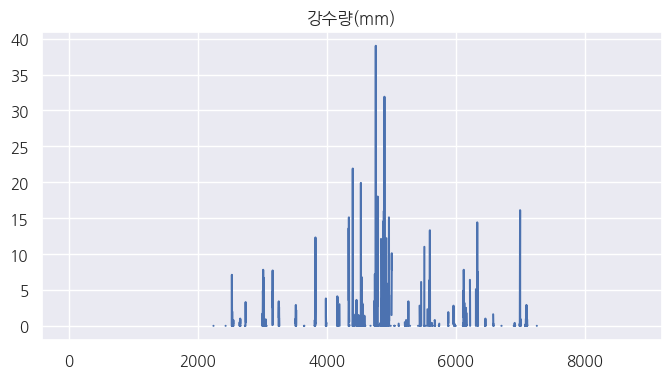

In [ ]:
# 변수가 내포하고 있는 의미 파악을 위한 추가 분석
plt.figure(figsize=(8, 4))
plt.plot(temp)
plt.title('강수량(mm)')
plt.show()

In [ ]:
# 위 정보로부터 파악한 내용을 서술해 보세요
# 결측치 0으로..?

### (3) 변수3

In [ ]:
# 변수가 수치형인지, 범주형인지 확인해 보세요
temp = weather_24['일사(MJ/m2)']
temp.dtype

dtype('float64')

In [ ]:
# 결측치 존재 여부를 확인하고 조치 방안을 검토해 보세요
temp.isnull().sum()

np.int64(3999)

In [ ]:
# 기초 통계량을 확인해 보세요
temp.describe()

,일사(MJ/m2)
count,4785.000000
mean,1.097177
std,0.988663
min,0.000000
25%,0.220000
50%,0.820000
75%,1.830000
max,3.810000


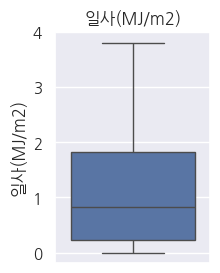

In [ ]:
# 데이터 분포를 시각해 보세요
plt.figure(figsize=(2, 3))
sns.boxplot(temp)
plt.title('일사(MJ/m2)')
plt.show()

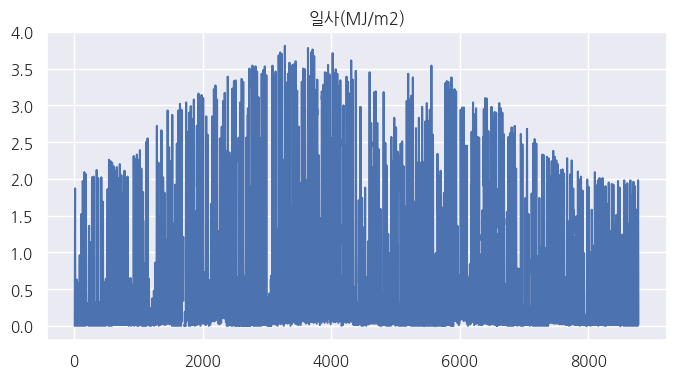

In [ ]:
# 변수가 내포하고 있는 의미 파악을 위한 추가 분석
plt.figure(figsize=(8, 4))
plt.plot(temp)
plt.title('일사(MJ/m2)')
plt.show()

In [ ]:
# 위 정보로부터 파악한 내용을 서술해 보세요
# ffill로 결측치 채우면 될듯

### (4) 변수4

In [ ]:
# 변수가 수치형인지, 범주형인지 확인해 보세요
temp = air_24['PM10']
temp.dtype

dtype('float64')

In [ ]:
# 결측치 존재 여부를 확인하고 조치 방안을 검토해 보세요
temp.isnull().sum()

np.int64(135)

In [ ]:
# 기초 통계량을 확인해 보세요
temp.describe()

,PM10
count,8649.000000
mean,30.660308
std,24.811649
min,3.000000
25%,17.000000
50%,26.000000
75%,38.000000
max,442.000000


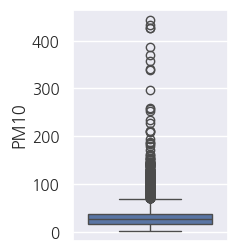

In [ ]:
# 데이터 분포를 시각해 보세요
plt.figure(figsize=(2, 3))
sns.boxplot(temp)
plt.show()

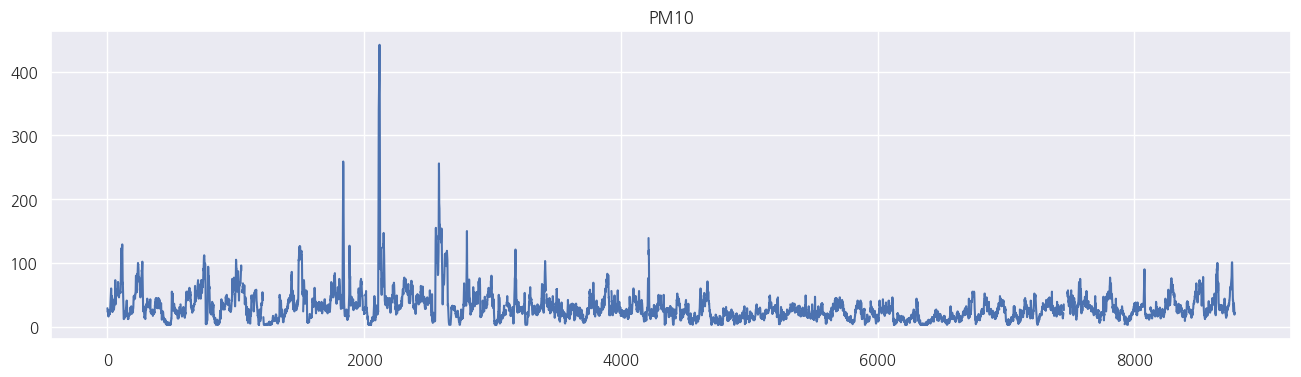

In [ ]:
# 변수가 내포하고 있는 의미 파악을 위한 추가 분석
plt.figure(figsize=(16, 4))
plt.plot(temp)
plt.title('PM10')
plt.show()

In [ ]:
# 위 정보로부터 파악한 내용을 서술해 보세요


## **3.EDA 2단계 - 데이터 전처리**
- 진행한 개별 변수 분석에 맞추어 데이터를 전처리 하겠습니다.

### (1) air_24, air_25, weather_24, weather_25 데이터 전처리
* air_24, air_25 각각 '측정일시'를 활용하여 'time'변수 생성
    * 참고: 미세먼지 데이터는 1시-24시, 날씨 데이터는 0시-23시로 구성되어 있습니다. [2-3]에서 미세먼지와 날씨 데이터를 time 기준으로 합치려면 기준이 동일해야 합니다. 미세먼지 데이터에서 time 변수 생성 시 이를 미리 고려(예: air_24['측정일시'] -1)하세요.
* time 변수를 pd.to_datetime으로 데이터 타입 변경
    * 참고: format = '%Y%m%d%H'

#### **1) air_24, air_25 의 '측정일시'를 활용하여 'time' 변수 생성**

In [ ]:
from datetime import datetime, timedelta

def zerofrom24(datetime, _format):
    datetime = str(datetime)
    try:
        return pd.to_datetime(datetime, format = _format)
    except:
        datetime = datetime[:-2] + '00'
        return pd.to_datetime(datetime, format = _format)+ timedelta(days=1)

air_24['time'] = air_24['측정일시'].map(lambda x : zerofrom24(x,'%Y%m%d%H'))
air_25['time'] = air_25['측정일시'].map(lambda x : zerofrom24(x,'%Y%m%d%H'))

In [ ]:
# 결과확인
print(air_24.shape)
air_24

(8784, 13)


,지역,망,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,PM25,주소,time
0,서울 종로구,도시대기,111123,종로구,2024010101,0.0031,1.21,0.0022,0.0425,29.0,23.0,서울 종로구 종로35가길 19,2024-01-01 01:00:00
1,서울 종로구,도시대기,111123,종로구,2024010102,0.0032,1.16,0.0020,0.0393,24.0,21.0,서울 종로구 종로35가길 19,2024-01-01 02:00:00
2,서울 종로구,도시대기,111123,종로구,2024010103,0.0030,1.00,0.0022,0.0359,23.0,19.0,서울 종로구 종로35가길 19,2024-01-01 03:00:00
3,서울 종로구,도시대기,111123,종로구,2024010104,0.0029,0.98,0.0021,0.0355,23.0,18.0,서울 종로구 종로35가길 19,2024-01-01 04:00:00
4,서울 종로구,도시대기,111123,종로구,2024010105,0.0031,1.02,0.0020,0.0371,25.0,21.0,서울 종로구 종로35가길 19,2024-01-01 05:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,서울 종로구,도시대기,111123,종로구,2024123120,0.0027,0.36,0.0284,0.0166,25.0,14.0,서울 종로구 종로35가길 19,2024-12-31 20:00:00
8780,서울 종로구,도시대기,111123,종로구,2024123121,0.0026,0.36,0.0257,0.0187,23.0,12.0,서울 종로구 종로35가길 19,2024-12-31 21:00:00
8781,서울 종로구,도시대기,111123,종로구,2024123122,0.0026,0.40,0.0204,0.0238,19.0,12.0,서울 종로구 종로35가길 19,2024-12-31 22:00:00
8782,서울 종로구,도시대기,111123,종로구,2024123123,0.0023,0.48,0.0135,0.0314,21.0,13.0,서울 종로구 종로35가길 19,2024-12-31 23:00:00


#### **2) weather_24, weather_25 의 '일시'를 활용하여 'time' 변수 생성**
* weather_24, weather_25 의 '일시'를 활용하여 'time'변수 생성
* time 변수를 pd.to_datetime으로 데이터 타입 변경

In [ ]:
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.
print(weather_24.shape)
weather_24['일시']

(8784, 38)


,일시
0,2024-01-01 0:00
1,2024-01-01 1:00
2,2024-01-01 2:00
3,2024-01-01 3:00
4,2024-01-01 4:00
...,...
8779,2024-12-31 19:00
8780,2024-12-31 20:00
8781,2024-12-31 21:00
8782,2024-12-31 22:00


In [ ]:
weather_24['time'] = pd.to_datetime(weather_24['일시'], format='%Y-%m-%d %H:%M')
weather_25['time'] = pd.to_datetime(weather_25['일시'], format='%Y-%m-%d %H:%M')

In [ ]:
# 결과확인
weather_24['time'].head()

,time
0,2024-01-01 00:00:00
1,2024-01-01 01:00:00
2,2024-01-01 02:00:00
3,2024-01-01 03:00:00
4,2024-01-01 04:00:00


#### **3) 'time' 기준으로 데이터 합치기**
* 미세먼지 데이터와 날씨 데이터를 'time' 기준으로 합쳐보세요.
    * df_24에는 'time' 기준으로 24년도 미세먼지, 날씨 데이터를 합쳐보세요.
    * df_25에는 'time' 기준으로 25년도 미세먼지, 날씨 데이터를 합쳐보세요.

In [ ]:
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.
df_24 = pd.merge(weather_24, air_24, on='time')
df_25 = pd.merge(weather_25, air_25, on='time')

In [ ]:
# 결과확인
print(df_24.shape)
df_24.head()

(8783, 51)


,지점,지점명,일시,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),...,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,PM25,주소
0,108,서울,2024-01-01 1:00,0.5,NaN,NaN,NaN,2.2,NaN,50.0,...,111123,종로구,2024010101,0.0031,1.21,0.0022,0.0425,29.0,23.0,서울 종로구 종로35가길 19
1,108,서울,2024-01-01 2:00,0.4,NaN,NaN,NaN,0.4,NaN,0.0,...,111123,종로구,2024010102,0.0032,1.16,0.0020,0.0393,24.0,21.0,서울 종로구 종로35가길 19
2,108,서울,2024-01-01 3:00,-0.1,NaN,NaN,NaN,1.7,NaN,20.0,...,111123,종로구,2024010103,0.0030,1.00,0.0022,0.0359,23.0,19.0,서울 종로구 종로35가길 19
3,108,서울,2024-01-01 4:00,-0.2,NaN,NaN,NaN,2.2,NaN,20.0,...,111123,종로구,2024010104,0.0029,0.98,0.0021,0.0355,23.0,18.0,서울 종로구 종로35가길 19
4,108,서울,2024-01-01 5:00,0.3,NaN,NaN,NaN,1.2,NaN,90.0,...,111123,종로구,2024010105,0.0031,1.02,0.0020,0.0371,25.0,21.0,서울 종로구 종로35가길 19


#### **4) 사용하지 않을 변수 제거**

* 머신러닝에 사용하지 않을 변수들을 제거해줍니다.
    * df_24, df_25에 사용할 변수들만 넣어보세요.
* time 변수를 기준으로 오름차순으로 정렬하세요

In [ ]:
df_24.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8783 entries, 0 to 8782
Data columns (total 51 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   지점             8783 non-null   int64         
 1   지점명            8783 non-null   object        
 2   일시             8783 non-null   object        
 3   기온(°C)         8783 non-null   float64       
 4   기온 QC플래그       0 non-null      float64       
 5   강수량(mm)        956 non-null    float64       
 6   강수량 QC플래그      1731 non-null   float64       
 7   풍속(m/s)        8752 non-null   float64       
 8   풍속 QC플래그       13 non-null     float64       
 9   풍향(16방위)       8752 non-null   float64       
 10  풍향 QC플래그       13 non-null     float64       
 11  습도(%)          8783 non-null   int64         
 12  습도 QC플래그       0 non-null      float64       
 13  증기압(hPa)       8783 non-null   float64       
 14  이슬점온도(°C)      8783 non-null   float64       
 15  현지기압(hPa)      8783 n

In [ ]:
# df_24, df_25에 사용할 변수들만 할당
drop_cols = [
    # 위치
    '지점', '지점명', '지역', '망', '측정소코드', '측정소명', '주소',

    # 시간 컬럼
    '일시', '측정일시',

    # QC 플래그
    '기온 QC플래그', '강수량 QC플래그', '풍속 QC플래그', '풍향 QC플래그', '습도 QC플래그', '현지기압 QC플래그', '해면기압 QC플래그',
    '일조 QC플래그', '일사 QC플래그', '지면온도 QC플래그',

    # 결측치 너무 많음
    '적설(cm)', '3시간신적설(cm)',

    # 코드성 변수
    '지면상태(지면상태코드)', '현상번호(국내식)',

    # 판단 어려움
    '운형(운형약어)'
]
df_24.drop(columns=drop_cols).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8783 entries, 0 to 8782
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   기온(°C)         8783 non-null   float64       
 1   강수량(mm)        956 non-null    float64       
 2   풍속(m/s)        8752 non-null   float64       
 3   풍향(16방위)       8752 non-null   float64       
 4   습도(%)          8783 non-null   int64         
 5   증기압(hPa)       8783 non-null   float64       
 6   이슬점온도(°C)      8783 non-null   float64       
 7   현지기압(hPa)      8783 non-null   float64       
 8   해면기압(hPa)      8783 non-null   float64       
 9   일조(hr)         4784 non-null   float64       
 10  일사(MJ/m2)      4785 non-null   float64       
 11  전운량(10분위)      8783 non-null   int64         
 12  중하층운량(10분위)    8783 non-null   int64         
 13  최저운고(100m )    4474 non-null   float64       
 14  시정(10m)        8783 non-null   int64         
 15  지면온도(°C)       8783 n

In [ ]:
# time 변수를 기준으로 오름차순으로 정렬
df_24 = df_24.drop(drop_cols, axis=1).sort_values(by='time', ascending=True)
df_25 = df_25.drop(drop_cols, axis=1).sort_values(by='time', ascending=True)

In [ ]:
df_24.head()

,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),증기압(hPa),이슬점온도(°C),현지기압(hPa),해면기압(hPa),일조(hr),...,10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C),time,SO2,CO,O3,NO2,PM10,PM25
0,0.5,NaN,2.2,50.0,97,6.1,0.0,1015.6,1026.5,NaN,...,-0.2,0.0,1.0,2024-01-01 01:00:00,0.0031,1.21,0.0022,0.0425,29.0,23.0
1,0.4,NaN,0.4,0.0,98,6.2,0.1,1016.2,1027.1,NaN,...,-0.2,0.0,1.0,2024-01-01 02:00:00,0.0032,1.16,0.0020,0.0393,24.0,21.0
2,-0.1,NaN,1.7,20.0,98,6.0,-0.3,1016.6,1027.5,NaN,...,-0.2,0.0,1.0,2024-01-01 03:00:00,0.0030,1.00,0.0022,0.0359,23.0,19.0
3,-0.2,NaN,2.2,20.0,98,5.9,-0.4,1016.8,1027.7,NaN,...,-0.2,0.0,1.0,2024-01-01 04:00:00,0.0029,0.98,0.0021,0.0355,23.0,18.0
4,0.3,NaN,1.2,90.0,99,6.2,0.1,1017.2,1028.1,NaN,...,-0.2,0.0,1.0,2024-01-01 05:00:00,0.0031,1.02,0.0020,0.0371,25.0,21.0


#### **5) 변수들의 결측치 처리**

In [ ]:
# df_24, df_25의 결측치 확인
print(df_24.isnull().sum())
print('-----------------------')
print(df_25.isnull().sum())

기온(°C)              0
강수량(mm)          7827
풍속(m/s)            31
풍향(16방위)           31
습도(%)               0
증기압(hPa)            0
이슬점온도(°C)           0
현지기압(hPa)           0
해면기압(hPa)           0
일조(hr)           3999
일사(MJ/m2)        3998
전운량(10분위)           0
중하층운량(10분위)         0
최저운고(100m )      4309
시정(10m)             0
지면온도(°C)            0
5cm 지중온도(°C)        0
10cm 지중온도(°C)       0
20cm 지중온도(°C)       0
30cm 지중온도(°C)       0
time                0
SO2               193
CO                100
O3                123
NO2               119
PM10              135
PM25              126
dtype: int64
-----------------------
기온(°C)              0
강수량(mm)          2673
풍속(m/s)             0
풍향(16방위)            0
습도(%)               0
증기압(hPa)            0
이슬점온도(°C)           0
현지기압(hPa)           0
해면기압(hPa)           0
일조(hr)           1379
일사(MJ/m2)        1379
전운량(10분위)           0
중하층운량(10분위)         0
최저운고(100m )      1778
시정(10m)             0
지면온도(°C)            0
5cm 지중온도(°C)     

In [ ]:
df_24[df_24['PM10'].isnull()]

,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),증기압(hPa),이슬점온도(°C),현지기압(hPa),해면기압(hPa),일조(hr),...,10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C),time,SO2,CO,O3,NO2,PM10,PM25
18,4.6,NaN,1.3,270.0,72,6.1,0.0,1014.7,1025.4,NaN,...,-0.2,0.1,1.0,2024-01-01 19:00:00,0.0037,0.66,0.0286,0.0218,NaN,19.0
179,-2.3,NaN,1.7,160.0,40,2.1,-14.1,1016.9,1027.9,1.0,...,0.1,0.4,1.2,2024-01-08 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN
180,-0.8,NaN,2.3,180.0,37,2.1,-13.7,1016.0,1026.9,1.0,...,0.2,0.4,1.2,2024-01-08 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN
181,-0.6,NaN,1.9,250.0,35,2.0,-14.2,1015.2,1026.1,1.0,...,0.2,0.4,1.2,2024-01-08 14:00:00,NaN,NaN,NaN,NaN,NaN,NaN
400,1.1,NaN,3.1,50.0,93,6.1,0.0,1012.5,1023.3,0.0,...,-0.1,0.2,0.9,2024-01-17 17:00:00,0.0032,0.72,0.0043,0.0440,NaN,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8317,4.7,NaN,3.2,270.0,29,2.5,-11.8,1013.4,1024.1,1.0,...,1.2,2.8,4.0,2024-12-12 14:00:00,NaN,NaN,NaN,NaN,NaN,NaN
8318,3.7,NaN,3.0,290.0,30,2.4,-12.3,1013.2,1023.9,0.6,...,1.4,2.8,4.0,2024-12-12 15:00:00,NaN,NaN,NaN,NaN,NaN,NaN
8319,3.3,NaN,3.0,290.0,28,2.2,-13.5,1012.8,1023.5,0.0,...,1.5,2.9,4.0,2024-12-12 16:00:00,0.0035,0.42,0.0268,0.0193,NaN,NaN
8652,1.5,NaN,3.9,270.0,39,2.7,-10.9,1013.3,1024.1,1.0,...,-0.2,1.0,2.0,2024-12-26 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# df_24, df_25의 변수 중 결측치를 처리(결측치 처리 방법은 다양!)
# 선택해서 결측치를 처리해보세요.
# 강수량은 0으로 채우기

df_24['강수량(mm)'] = df_24['강수량(mm)'].fillna(0)
df_25['강수량(mm)'] = df_25['강수량(mm)'].fillna(0)

# 나머지 컬럼은 ffill → bfill로 채우기
df_24 = df_24.ffill().bfill()
df_25 = df_25.ffill().bfill()

In [ ]:
# df_24, df_25의 결측치 재확인 해보기
# df_24, df_25의 결측치 확인
print(df_24.isnull().sum())
print('-----------------------')
print(df_25.isnull().sum())

기온(°C)           0
강수량(mm)          0
풍속(m/s)          0
풍향(16방위)         0
습도(%)            0
증기압(hPa)         0
이슬점온도(°C)        0
현지기압(hPa)        0
해면기압(hPa)        0
일조(hr)           0
일사(MJ/m2)        0
전운량(10분위)        0
중하층운량(10분위)      0
최저운고(100m )      0
시정(10m)          0
지면온도(°C)         0
5cm 지중온도(°C)     0
10cm 지중온도(°C)    0
20cm 지중온도(°C)    0
30cm 지중온도(°C)    0
time             0
SO2              0
CO               0
O3               0
NO2              0
PM10             0
PM25             0
dtype: int64
-----------------------
기온(°C)           0
강수량(mm)          0
풍속(m/s)          0
풍향(16방위)         0
습도(%)            0
증기압(hPa)         0
이슬점온도(°C)        0
현지기압(hPa)        0
해면기압(hPa)        0
일조(hr)           0
일사(MJ/m2)        0
전운량(10분위)        0
중하층운량(10분위)      0
최저운고(100m )      0
시정(10m)          0
지면온도(°C)         0
5cm 지중온도(°C)     0
10cm 지중온도(°C)    0
20cm 지중온도(°C)    0
30cm 지중온도(°C)    0
time             0
SO2              0
CO               0
O3           

#### **6) 전일 같은 시간 미세먼지 농도 변수 추가**

* 먼저 df_24, df_25에 month, day, hour 변수를 추가하세요.
    * 예) dt.month, dt.day, dt.hour 사용 또는 datetimeindex에서는 df.index.month 등 사용 가능
* 모델링에 유용한 변수로 전일 같은 시간(24시간 전) 미세먼지 농도 변수를 추가하세요.
    * 시계열 데이터 처리를 위한 shift 연산을 참고하세요.

In [ ]:
# df_24, df_25의 time을  month, day, hour 로 쪼개기 (year는 필요 없음). 이후에 저장 시 index(time)은 포함하지 않음.
for data in (df_24, df_25):
    data['month'] = data['time'].dt.month
    data['day'] = data['time'].dt.day
    data['hour'] = data['time'].dt.hour
    data.drop('time', axis=1, inplace=True)

In [ ]:
# 확인해보기
df_24.head()

,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),증기압(hPa),이슬점온도(°C),현지기압(hPa),해면기압(hPa),일조(hr),...,30cm 지중온도(°C),SO2,CO,O3,NO2,PM10,PM25,month,day,hour
0,0.5,0.0,2.2,50.0,97,6.1,0.0,1015.6,1026.5,0.0,...,1.0,0.0031,1.21,0.0022,0.0425,29.0,23.0,1,1,1
1,0.4,0.0,0.4,0.0,98,6.2,0.1,1016.2,1027.1,0.0,...,1.0,0.0032,1.16,0.0020,0.0393,24.0,21.0,1,1,2
2,-0.1,0.0,1.7,20.0,98,6.0,-0.3,1016.6,1027.5,0.0,...,1.0,0.0030,1.00,0.0022,0.0359,23.0,19.0,1,1,3
3,-0.2,0.0,2.2,20.0,98,5.9,-0.4,1016.8,1027.7,0.0,...,1.0,0.0029,0.98,0.0021,0.0355,23.0,18.0,1,1,4
4,0.3,0.0,1.2,90.0,99,6.2,0.1,1017.2,1028.1,0.0,...,1.0,0.0031,1.02,0.0020,0.0371,25.0,21.0,1,1,5


In [ ]:
# df_24, df_25에 전일 같은 시간 미세먼지 농도 변수(PM10_lag1) 추가
# 전일 같은 시간은 24시간 전 입니다. (shift 함수 활용)
df_24['PM10_lag1'] = df_24['PM10'].shift(24)
df_25['PM10_lag1'] = df_25['PM10'].shift(24)


In [ ]:
#확인해보기!
df_24.loc[df_24['hour'] == 1, ['month', 'day', 'hour', 'PM10_lag1', 'PM10']]

,month,day,hour,PM10_lag1,PM10
0,1,1,1,NaN,29.0
24,1,2,1,29.0,41.0
48,1,3,1,41.0,29.0
72,1,4,1,29.0,59.0
96,1,5,1,59.0,54.0
...,...,...,...,...,...
8664,12,27,1,54.0,28.0
8688,12,28,1,28.0,21.0
8712,12,29,1,21.0,21.0
8736,12,30,1,21.0,36.0


#### **7) t+1 시점의 미세먼지 농도 데이터 생성**
* t+1 시점은 1시간 후 입니다.
* t+1 시점의 미세먼지 농도 변수(PM10_1)를 생성하세요.
* t+1 시점의 미세먼지 농도는 머신러닝 모델을 통해 예측하려는 y값(target) 입니다.

In [ ]:
# df_24, df_25에 t+1 시점 변수(PM10_1) 추가
# shift 함수 활용 해보기!

# df_24, df_25에 전일 같은 시간 미세먼지 농도 변수(PM10_lag1) 추가
# 전일 같은 시간은 24시간 전 입니다. (shift 함수 활용)
df_24['PM10_1'] = df_24['PM10'].shift(-1)
df_25['PM10_1'] = df_25['PM10'].shift(-1)

In [ ]:
#확인해보기!
df_24[['month', 'day', 'hour', 'PM10_1', 'PM10']]

,month,day,hour,PM10_1,PM10
0,1,1,1,24.0,29.0
1,1,1,2,23.0,24.0
2,1,1,3,23.0,23.0
3,1,1,4,25.0,23.0
4,1,1,5,26.0,25.0
...,...,...,...,...,...
8778,12,31,19,25.0,30.0
8779,12,31,20,23.0,25.0
8780,12,31,21,19.0,23.0
8781,12,31,22,21.0,19.0


In [ ]:
# 결측치가 있다면 처리하고 확인해보기!
df_24 = df_24.dropna(axis=0)
df_25 = df_25.dropna(axis=0)

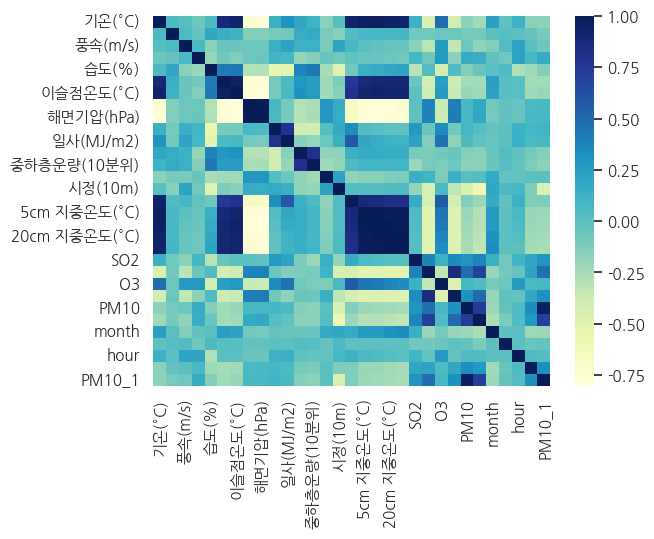

In [ ]:
sns.heatmap(df_24.corr(), cmap='YlGnBu')
plt.show()

### (2) train, test 데이터 분리 및 저장

* 24년도 데이터(df_24)를 train 데이터로 저장하세요. y 값을 제외하고 train_x로 저장한 후 y 값은 train_y로 저장하세요.
* 25년도 데이터(df_25)를 test 데이터로 저장하세요. y 값을 제외하고 test_x로 저장한 후 y 값은 test_y로 저장하세요.
* train_x, test_x 에서 'time' 변수 (또는 인덱스)는 제외헤주세요
* y값은 'PM10_1' 즉, t+1 시점의 미세먼지 농도입니다.
* 각각의 데이터프레임을 csv 파일로 저장하세요. (train_x.csv / train_y.csv / test_x.csv / test_y.csv) (단, 인덱스 제외)


In [ ]:
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.
train_x = df_24.drop('PM10_1', axis=1)
train_y = df_24.loc[:, 'PM10_1']
test_x = df_25.drop('PM10_1', axis=1)
test_y = df_25.loc[:, 'PM10_1']

In [ ]:
print(train_x.shape, train_y.shape, test_x.shape, test_y.shape)

(8758, 30) (8758,) (2855, 30) (2855,)


★ csv 파일이 잘 생성되었는지 확인하세요. 혹시 모르니 저장해두는 것을 추천드립니다. ★

In [ ]:
# 각각의 데이터프레임을 csv 파일로 저장 (train_x.csv / train_y.csv / test_x.csv / test_y.csv)
train_y.to_csv('train_y.csv', encoding='cp949', index=False)
train_x.to_csv('train_x.csv', encoding='cp949', index=False)
test_y.to_csv('test_y.csv', encoding='cp949', index=False)
test_x.to_csv('test_x.csv', encoding='cp949', index=False)

## [step 3] 모델링

## **0.프로젝트 소개**

### (1) 수행 목표
- 미세먼지 농도를 예측하는 머신러닝 모델을 만드세요.

#### 우리가 풀어야 하는 문제는 무엇인가요?
* 서울 지역의 미세먼지 데이터와 날씨 데이터를 활용하여,
미세먼지 예측에 관련 있는 데이터 항목으로 데이터를 구성, 전처리 하여
미세먼지 농도를 예측하는 머신러닝 모델 구현


### (2) 데이터 소개

#### 1) 기본 데이터

* 학습 데이터
    * air_2024.csv : 2024년 미세먼지 데이터
    * weather_2024.csv : 2024년 날씨 데이터
* 테스트 데이터
    * air_2025.csv : 2025년 미세먼지 데이터
    * weather_2025.csv : 2025년 날씨 데이터

#### 2) 데이터셋의 변수 소개(weather_202x)

* 증기압: 증기가 고체 또는 액체와 동적 평형 상태에 있을 때 증기의 압력 (증기가 되려는 힘)
* 이슬점 온도: 불포화 상태의 공기가 냉각될 때, 포화 상태에 도달하여 수증기의 응결이 시작되는 온도
* 일조: 일정한 물체나 땅의 겉면에 태양 광선이 비치는 시간 (1시간 중 비율)
* 일사(량): 태양으로부터 오는 태양 복사 에너지가 지표에 닿는 양 (면적당 에너지 량)
* 전운량: 하늘을 육안으로 관측하여 전부 구름일 때 10, 구름이 덮고 있는 하늘의 비율에 따라 0~10
* 중하층운량: 중층과 하층에 있는 구름의 분포량(중하층 구름이 날씨에 영향 주므로 따로 표기)
* 운형(운형약어): 구름의 종류. 약어 코드로 기재됨
* 최저운고: 가장 낮은 구름의 높이
* 현상번호(국내식): 비, 소낙비, 싸락눈, 눈보라 등의 기상현상을 나타낸 코드번호
* 지면온도: 지면 0cm 온도
* 지중온도: 땅 속 온도변수1

## **1.환경설정**

* 세부 요구사항
    - 경로 설정 : 프로젝트 폴더를 준비하고 데이터를 로딩하시오.
        * 구글코랩
            * 구글 드라이브에 project 폴더를 만들고,
            * 데이터 파일을 복사해 넣습니다.
        * (필요시) 로컬 수행(Ananconda)
            * 제공된 압축파일을 다운받아 압축을 풀고
            * anaconda의 root directory(보통 C:/Users/< ID > 에 project 폴더를 만들고, 복사해 넣습니다.
            
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.

### (1) 경로 설정
* 구글 코랩 (또는 필요시 로컬)를 사용하시면 됩니다.

#### 1) 구글 코랩 수행

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/Aivle/미니프로젝트/1차_미세먼지/'

#### 1) (희망시) 로컬 수행(Anaconda)
* project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [ ]:
# path = 'C:/Users/User/project/'
# path = 'C:/Users/User/checking/'

### (2) 라이브러리 설치 및 불러오기

#### 1) 라이브러리 설치 및 로딩

In [ ]:
# 필요한 라이브러리 설치 및 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import joblib

from statsmodels.graphics.mosaicplot import mosaic
from scipy import stats as spst
import statsmodels.api as sm
import joblib

# 더 필요한 라이브러리를 아래에 추가합니다.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import joblib


> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
<small>(해결되지 않는다면 아래 Colab 한글 깨짐 현상 해결법 참고)<br>https://developnote.tistory.com/165#google_vignette </small>

In [ ]:
# (Jupyter) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
plt.rc('font', family='Malgun Gothic')
sns.set(font="Malgun Gothic",#"NanumGothicCoding",
        rc={"axes.unicode_minus":False}, # 마이너스 부호 깨짐 현상 해결
        style='darkgrid')

In [ ]:
# (Colab) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
!apt -qq -y install fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

import matplotlib as mpl
import matplotlib.font_manager as fm
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

### (3) 데이터 불러오기
* 주어진 데이터셋
    * 미세먼지 및 날씨 데이터 : train_x.csv / train_y.csv / test_x.csv / test_y.csv

#### 1) 데이터 로딩

In [ ]:
%cd '{path}'

/content/drive/MyDrive/Aivle/미니프로젝트/1차_미세먼지


In [ ]:
# train_x.csv / train_y.csv / test_x.csv / test_y.csv 4개의 데이터 로딩
train_x = pd.read_csv('train_x.csv', encoding='cp949')
train_y = pd.read_csv('train_y.csv', encoding='cp949')
test_x = pd.read_csv('test_x.csv', encoding='cp949')
test_y = pd.read_csv('test_y.csv', encoding='cp949')

#### 2) 기본 정보 조회
* 로딩한 데이터의 기본 정보를 확인 합니다

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.

In [ ]:
train_x.head()

,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),증기압(hPa),이슬점온도(°C),현지기압(hPa),해면기압(hPa),일조(hr),...,SO2,CO,O3,NO2,PM10,PM25,month,day,hour,PM10_lag1
0,3.5,0.0,1.1,270.0,85,6.7,1.2,1013.6,1024.3,0.0,...,0.0032,0.65,0.0286,0.0163,41.0,36.0,1,2,1,29.0
1,3.3,0.0,2.0,270.0,86,6.6,1.1,1013.5,1024.2,0.0,...,0.0031,0.68,0.0248,0.0175,44.0,38.0,1,2,2,24.0
2,3.0,0.0,2.2,270.0,80,6.1,-0.1,1013.5,1024.2,0.0,...,0.0030,0.60,0.0321,0.0116,47.0,43.0,1,2,3,23.0
3,2.8,0.0,0.4,0.0,82,6.1,0.0,1012.9,1023.6,0.0,...,0.0028,0.61,0.0326,0.0106,48.0,40.0,1,2,4,23.0
4,2.4,0.0,0.1,0.0,84,6.1,0.0,1012.3,1023.1,0.0,...,0.0029,0.63,0.0267,0.0157,53.0,47.0,1,2,5,25.0


In [ ]:
train_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8758 entries, 0 to 8757
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   기온(°C)         8758 non-null   float64
 1   강수량(mm)        8758 non-null   float64
 2   풍속(m/s)        8758 non-null   float64
 3   풍향(16방위)       8758 non-null   float64
 4   습도(%)          8758 non-null   int64  
 5   증기압(hPa)       8758 non-null   float64
 6   이슬점온도(°C)      8758 non-null   float64
 7   현지기압(hPa)      8758 non-null   float64
 8   해면기압(hPa)      8758 non-null   float64
 9   일조(hr)         8758 non-null   float64
 10  일사(MJ/m2)      8758 non-null   float64
 11  전운량(10분위)      8758 non-null   int64  
 12  중하층운량(10분위)    8758 non-null   int64  
 13  최저운고(100m )    8758 non-null   float64
 14  시정(10m)        8758 non-null   int64  
 15  지면온도(°C)       8758 non-null   float64
 16  5cm 지중온도(°C)   8758 non-null   float64
 17  10cm 지중온도(°C)  8758 non-null   float64
 18  20cm 지중온

In [ ]:
train_x.describe()

,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),증기압(hPa),이슬점온도(°C),현지기압(hPa),해면기압(hPa),일조(hr),...,SO2,CO,O3,NO2,PM10,PM25,month,day,hour,PM10_lag1
count,8758.000000,8758.000000,8758.000000,8758.000000,8758.000000,8758.000000,8758.000000,8758.000000,8758.000000,8758.000000,...,8758.000000,8758.000000,8758.000000,8758.000000,8758.000000,8758.000000,8758.000000,8758.000000,8758.00000,8758.000000
mean,14.904830,0.149737,2.315186,177.322448,65.759648,13.612252,8.002832,1005.419559,1015.602900,0.281857,...,0.002955,0.410886,0.034427,0.019551,30.637703,18.935944,6.528774,15.797100,11.50000,30.551838
std,10.899197,1.180158,1.128257,106.761537,17.527828,9.330905,11.404798,7.587499,7.996082,0.392907,...,0.000668,0.168453,0.021402,0.013257,24.750608,13.601051,3.443441,8.788394,6.92119,24.680981
min,-14.000000,0.000000,0.000000,0.000000,14.000000,1.100000,-21.500000,984.600000,994.200000,0.000000,...,0.001500,0.100000,0.001300,0.002800,3.000000,1.000000,1.000000,1.000000,0.00000,3.000000
25%,4.800000,0.000000,1.500000,50.000000,53.000000,5.400000,-1.700000,999.100000,1008.800000,0.000000,...,0.002500,0.300000,0.020600,0.010500,17.000000,10.000000,4.000000,8.000000,6.00000,17.000000
50%,16.000000,0.000000,2.200000,200.000000,67.000000,11.400000,8.900000,1005.500000,1015.700000,0.000000,...,0.002800,0.370000,0.031650,0.015600,26.000000,16.000000,7.000000,16.000000,11.50000,26.000000
75%,24.400000,0.000000,3.000000,270.000000,80.000000,20.000000,17.500000,1011.700000,1022.200000,0.600000,...,0.003300,0.480000,0.044600,0.024200,38.000000,25.000000,10.000000,23.000000,17.00000,37.000000
max,36.300000,39.000000,7.500000,360.000000,100.000000,35.900000,27.100000,1023.300000,1034.200000,1.000000,...,0.007600,1.560000,0.177300,0.106400,442.000000,96.000000,12.000000,31.000000,23.00000,442.000000


## **2.머신러닝 모델링**

### (1) 모델링: LinearRegression

* Train과 Test로 나눈 데이터를 기준으로 LinearRegression 모델링을 진행하고 평가를 해주세요.
* 그리고 모델 파일을 pkl로 저장해주세요.
* 성능지표 : MSE, R2 Score(소수점 다섯째 자리까지)

In [ ]:
# LinearRegression 코드를 작성하세요.
model = LinearRegression()
model.fit(train_x, train_y)


LinearRegression()

In [ ]:
# predict로 예측하여 y_pred_LR에 저장해보세요.
y_pred_LR = model.predict(test_x)

In [ ]:
# test_y 데이터와 y_pred_LR 데이터로 성능을 평가하여 출력해보세요.
# 성능지표는 mse와 r2를 이용하세요.
print('mse:', mean_squared_error(test_y, y_pred_LR))
print('R2:', r2_score(test_y, y_pred_LR))

mse: 51.56159460015927
R2: 0.9319267254091076


In [ ]:
# 학습한 모델을 pkl 파일로 저장해보세요.
joblib.dump(model, 'LR_model.pkl')

['LR_model.pkl']

### (2) 모델링: RandomForest

* 랜덤포레스트: 배깅의 일종으로 의사결정나무(Decision Tree) 여러 개를 모아서 숲을 랜덤으로 구성하고 이를 종합해서 최종 모델을 산출하는 기법
* Train과 Test로 나눈 데이터를 기준으로 렌덤포레스트로 모델을 학습을 진행하고 평가를 해주세요.
* 그리고 모델 파일을 pkl로 저장해주세요.
* 성능지표 : MSE, R2 Score(소수점 다섯째 자리까지)

In [ ]:
# 랜덤포레스트로 모델 학습 진행하고 성능을 평가하여 출력해 보세요.
# 성능평가는 MSE, R2 Score
model = RandomForestRegressor()
model.fit(train_x, train_y)
y_pred_RF = model.predict(test_x)
print('mse:', mean_squared_error(test_y, y_pred_RF))
print('R2:', r2_score(test_y, y_pred_RF))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


mse: 63.36674248686514
R2: 0.9163411897035199


In [ ]:
# 랜덤포레스트로 모델 학습 진행하고 성능을 평가하여 출력해 보세요.
# 성능평가는 MSE, R2 Score
params = {
    'n_estimators':[100, 200, 300],
    'max_depth' : [5, 10, 15],
    'min_samples_leaf' : [1, 2, 4],
    'min_samples_split' : [5, 10, 15]
}
model_grid = RandomizedSearchCV(RandomForestRegressor(), param_distributions=params, n_iter=20, verbose=1, cv=3)
model_grid.fit(train_x, train_y.values.ravel())
print(model_grid.best_params_)
print(model_grid.best_score_)

model = model_grid.best_estimator_
y_pred_RF = model.predict(test_x)
print('mse:', mean_squared_error(test_y, y_pred_RF))
print('R2:', r2_score(test_y, y_pred_RF))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'n_estimators': 100, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_depth': 15}
0.8280345553307865
mse: 55.43521903817892
R2: 0.9268126419119598


In [ ]:
# 학습한 모델을 파일로 저장해보세요.
joblib.dump(model, 'RF_model.pkl')

['RF_model.pkl']

### (2-1) 랜덤포레스트 feature_importances 확인
* 렌덤포레스트로 학습한 모델의 feature_importances를 구해보세요.

In [ ]:
# 렌덤포레스트로 학습한 모델의 feature_importances를 구해보세요.
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.

print(model.feature_importances_)

[2.13648698e-03 5.04591004e-04 1.36873280e-03 6.34959631e-04
 1.88283672e-03 3.49279777e-04 4.30201453e-04 5.61065664e-04
 5.55679722e-04 4.55140522e-04 1.60599014e-03 3.73162109e-04
 3.60257034e-04 1.06306620e-03 9.48035481e-03 5.11218818e-03
 3.44514010e-04 3.13803640e-04 3.99273829e-04 5.08657829e-04
 7.73213509e-04 1.56069266e-03 1.41849855e-03 1.44318077e-03
 9.60488156e-01 1.12241895e-03 2.48025327e-04 7.22337577e-04
 2.11238339e-03 1.67085111e-03]


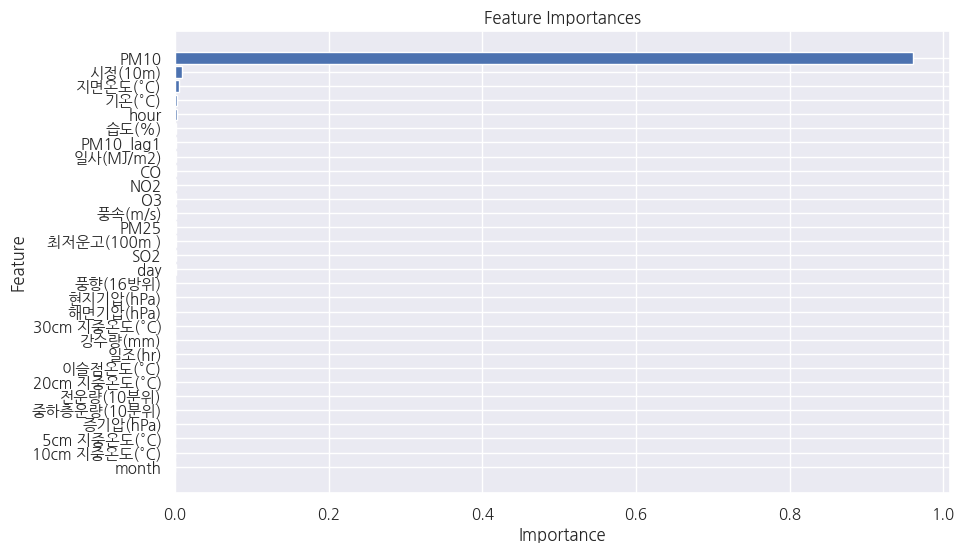

In [ ]:
# feature_importances 시각화
fi_df = pd.DataFrame({'feature': train_x.columns , 'importance': model.feature_importances_}).sort_values(by='importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(fi_df['feature'], fi_df['importance'])
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [ ]:
# 확인 후 알 수 있었던 인사이트가 있었으면 정리해보세요!
# PM10 에 너무 치중되어있음

### (3) 모델링: GradientBoosting

* GradientBoosting: 앞선 모델의 에러를 다음 모델의 예측 값으로 활용하면서 가중치 업데이트 하는데 경사하강법(Gradient Descent)를 활용해서 최적 모델을 만드는 기법
* Train과 Test로 나눈 데이터를 기준으로 그라디언트부스팅으로 모델을 학습을 진행하고 평가를 해주세요.
* 그리고 모델 파일을 pkl로 저장해주세요.
* 성능지표 : MSE, R2 Score(소수점 다섯째 자리까지)

In [ ]:
# 모델 학습 진행 하고 성능을 평가하여 출력해 보세요.
# 성능평가는 MSE, R2 Score
model = GradientBoostingRegressor()
model.fit(train_x, train_y)
y_pred_GB = model.predict(test_x)
print('mse:', mean_squared_error(test_y, y_pred_GB))
print('R2:', r2_score(test_y, y_pred_GB))

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


mse: 49.09367917411695
R2: 0.9351849466834271


In [ ]:
params = {
    'n_estimators':[100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    'max_depth' : [2, 3, 5],
    'min_samples_leaf' : [1, 2, 4],
    'min_samples_split' : [5, 10, 15]
}
model_grid = RandomizedSearchCV(GradientBoostingRegressor(), param_distributions=params, n_iter=30, verbose=1, cv=3)
model_grid.fit(train_x, train_y.values.ravel())
print(model_grid.best_params_)
print(model_grid.best_score_)

model = model_grid.best_estimator_
y_pred_GB = model.predict(test_x)
print('mse:', mean_squared_error(test_y, y_pred_GB))
print('R2:', f'{r2_score(test_y, y_pred_GB):.5}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.1}
0.8456817409162184
mse: 48.3220576802572
R2: 0.9362


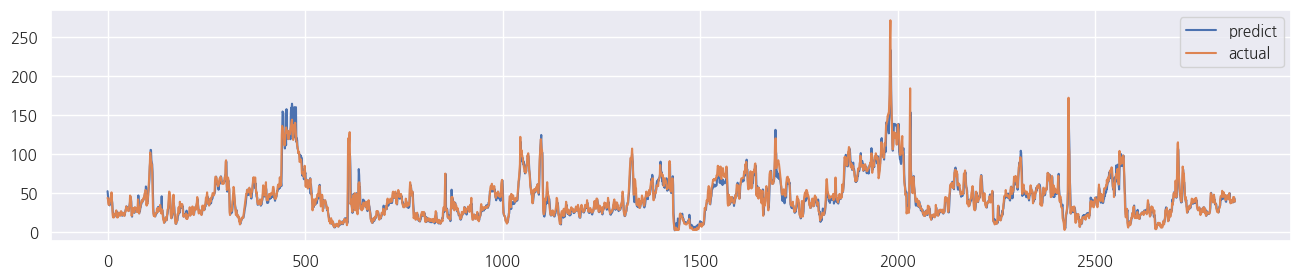

In [ ]:
plt.figure(figsize=(16,3))
plt.plot(y_pred_GB, label='predict')
plt.plot(test_y, label='actual')
plt.legend()
plt.show()

In [ ]:
# 학습한 모델을 파일로 저장해보세요.
joblib.dump(model, 'GB_model.pkl')


['GB_model.pkl']

### (3-1) 그라디언트부스팅 feature_importances 확인
* 학습한 모델의 feature_importances를 구해보세요.

In [ ]:
# 그라디언트부스팅으로 학습한 모델의 feature_importances를 구해보세요.
# 아래에 필요한 코드를 작성하고 결과를 확인합니다.

print(model.feature_importances_)

[1.10616682e-04 8.00711124e-04 9.48180422e-04 5.28668733e-04
 1.85034617e-03 3.78572707e-04 4.25042077e-04 2.24045172e-04
 3.66708008e-04 3.97675151e-04 1.73034315e-03 5.11092619e-04
 1.31678740e-04 4.24553380e-04 1.38371682e-02 1.58117166e-02
 1.47797620e-04 7.13903161e-05 2.30276173e-04 1.86387754e-04
 2.76368951e-04 1.55231822e-03 8.05393465e-04 4.69169269e-04
 9.47862182e-01 4.27562799e-03 1.20407256e-04 3.28294086e-04
 4.64707042e-03 5.50197486e-04]


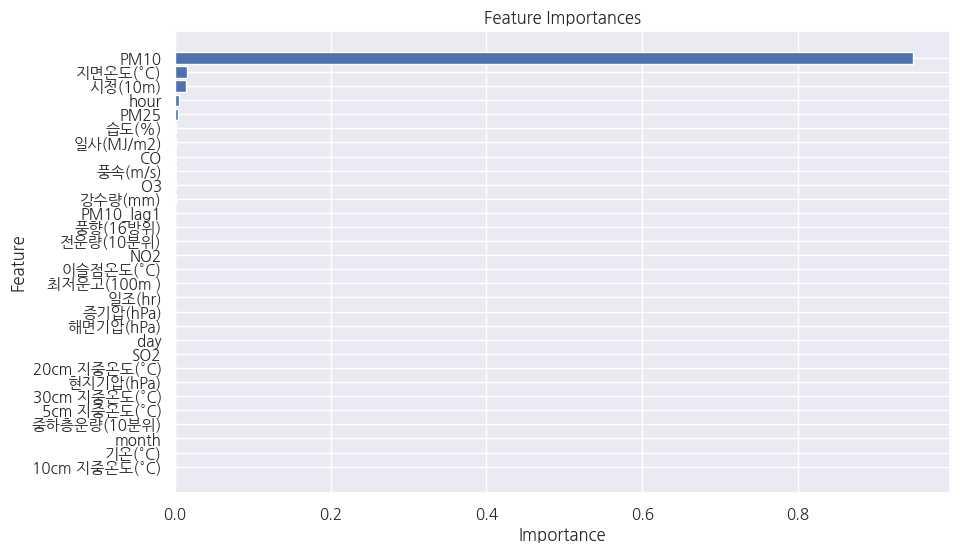

In [ ]:
# feature_importances 시각화
fi_df = pd.DataFrame({'feature': train_x.columns , 'importance': model.feature_importances_}).sort_values(by='importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(fi_df['feature'], fi_df['importance'])
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### (4) 모델링: Self Choice Model

* Self Choice Model: 앞선 교육과정에서 배운 머신러닝 모델 중 어떤 것이든 좋습니다. 원하는 모델을 선택해서 학습을 시켜보세요.
* Train과 Test로 나눈 데이터를 기준으로 Self Choice Model로 모델을 학습을 진행하고 평가를 해주세요.
* 그리고 모델 파일을 pkl로 저장해주세요.
* 성능지표 : MSE, R2 Score(소수점 다섯째 자리까지)

In [ ]:
# 모델 학습 진행 하고 성능을 평가하여 출력해 보세요.
# (예시)xgboost 등
from xgboost import XGBRegressor

params = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 1, 3],
    "reg_lambda": [0.5, 1.0, 1.5],
    "reg_alpha": [0, 0.1, 0.5],
}

model_grid = RandomizedSearchCV(XGBRegressor(), param_distributions=params, n_iter=30, cv=3, n_jobs=-1, verbose=1)
model_grid.fit(train_x, train_y.values.ravel())
print(model_grid.best_params_)
print(model_grid.best_score_)

model = model_grid.best_estimator_
y_pred_XGB = model.predict(test_x)
print('mse:', mean_squared_error(test_y, y_pred_XGB))
print('R2:', f'{r2_score(test_y, y_pred_XGB):.5}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
{'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 3, 'colsample_bytree': 1.0}
0.8387106870295792
mse: 49.86905288696289
R2: 0.93416


In [ ]:
# 학습한 모델을 파일로 저장해보세요.
joblib.dump(model, 'XGB_model.pkl')

['XGB_model.pkl']

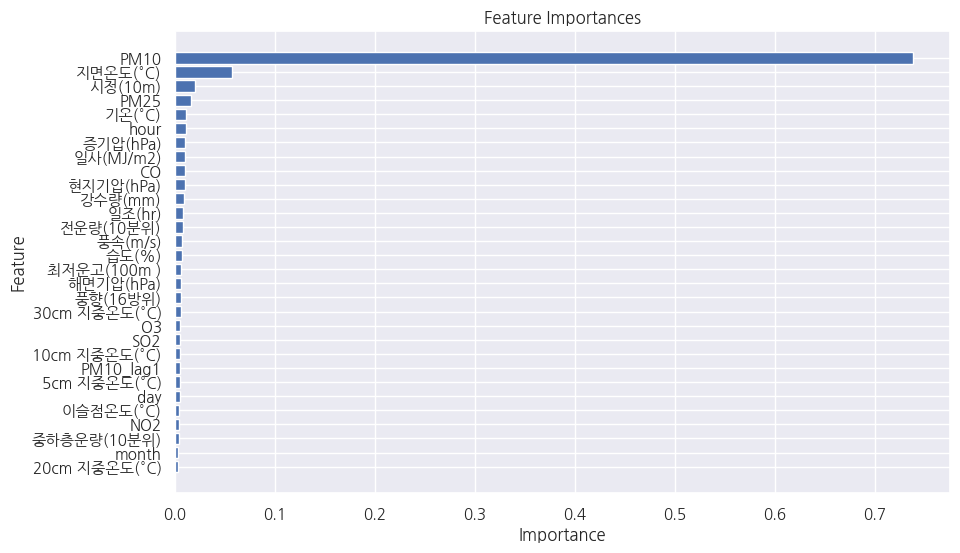

In [ ]:
# (다음 진행은 선택입니다)
# self choice model로 학습한 모델의 feature_importances를 구해보세요.
# 확인할 수 있는 내용으로 우리 모델에서의 인사이트를 정리해보세요.
# Feature의 중요도 확인 및 시각화
fi_df = pd.DataFrame({'feature': train_x.columns , 'importance': model.feature_importances_}).sort_values(by='importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(fi_df['feature'], fi_df['importance'])
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# 고생하셨습니다👍👍